This notebook shows how integer partition distributions can be computed for models of ancient gene flow and how they can be recorded from genealogies in tskit format.

In [1]:
import sys
import tskit
import msprime
import numpy as np
import demesdraw
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import random
import itertools
import scipy.linalg
np.set_printoptions(threshold=sys.maxsize)

We consider a sample of 5 unlabelled lineages. The code below will work for arbitrary sample sizes, but calculations beyond 9 lineages become too slow to be useful.

In [2]:
n = 5

The first step is to enumerate the states in the continuous time Markov Chain. These are integer partitions distributed across two populations. The code below obtains these by doing a recursion over the coalescent history for a panmictic pop and then splitting the integer partitions over two pops.

In [3]:
state_list = []

state = [1]*n
state_list.append(state)

# from itertools recipes (https://docs.python.org/3/library/itertools.html)
def powerset(iterable):
    "Subsequences of the iterable from shortest to longest."
    # powerset([1,2,3]) → () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)
    s = list(iterable)
    return itertools.chain.from_iterable(itertools.combinations(s, r) for r in range(len(s)+1))

def split_across_pops(state):
    split_states = []
    for ps in powerset(state):
        orig_state = state.copy()
        next_split_state_1 = [[], []]
        next_split_state_2 = [[], []]
        next_split_state_1[0] = list(ps)
        next_split_state_2[1] = list(ps)
        for i in ps:
            orig_state.remove(i)
        next_split_state_1[1] = orig_state
        next_split_state_2[0] = orig_state
        if next_split_state_1 not in split_states:
            split_states.append(next_split_state_1)
        if next_split_state_2 not in split_states:
            split_states.append(next_split_state_2)
    split_states.sort()
    return split_states

def get_next_state(state, state_list):
    for pair in itertools.combinations(state, 2):
        next_state = state.copy()
        next_state.remove(pair[0])
        next_state.remove(pair[1])
        next_state += [pair[0] + pair[1]]
        next_state.sort(reverse=True)
        if next_state not in state_list:
            state_list.append(next_state)
            get_next_state(next_state, state_list)
    state_list.sort()
    
    two_pop_states = []
    state_dict = {}
    tp_counter = 0
    for s_idx, s in enumerate(state_list):
        tps = split_across_pops(s)
        two_pop_states += tps
        for j in range(tp_counter, tp_counter + len(tps)):
            state_dict[j] = s_idx
        tp_counter += len(tps)
    return state_list, two_pop_states, state_dict

    
state_list, two_pop_state_list, state_dict = get_next_state(state, state_list)

print("")
print("Number of integer partitions for n={}: {}".format(n, len(state_list)))
print(state_list)
print("")
print("Number of states for n={} split over two pops: {}".format(n, len(two_pop_state_list)))
print(two_pop_state_list)


Number of integer partitions for n=5: 7
[[1, 1, 1, 1, 1], [2, 1, 1, 1], [2, 2, 1], [3, 1, 1], [3, 2], [4, 1], [5]]

Number of states for n=5 split over two pops: 36
[[[], [1, 1, 1, 1, 1]], [[1], [1, 1, 1, 1]], [[1, 1], [1, 1, 1]], [[1, 1, 1], [1, 1]], [[1, 1, 1, 1], [1]], [[1, 1, 1, 1, 1], []], [[], [2, 1, 1, 1]], [[1], [2, 1, 1]], [[1, 1], [2, 1]], [[1, 1, 1], [2]], [[2], [1, 1, 1]], [[2, 1], [1, 1]], [[2, 1, 1], [1]], [[2, 1, 1, 1], []], [[], [2, 2, 1]], [[1], [2, 2]], [[2], [2, 1]], [[2, 1], [2]], [[2, 2], [1]], [[2, 2, 1], []], [[], [3, 1, 1]], [[1], [3, 1]], [[1, 1], [3]], [[3], [1, 1]], [[3, 1], [1]], [[3, 1, 1], []], [[], [3, 2]], [[2], [3]], [[3], [2]], [[3, 2], []], [[], [4, 1]], [[1], [4]], [[4], [1]], [[4, 1], []], [[], [5]], [[5], []]]


We now define the rate matrix for transitions between these states. The code below compares all pairs of states and checks whether a migration or a coalescence can explain their difference.

In [4]:
Q = np.zeros((len(two_pop_state_list), len(two_pop_state_list)))

# we can set the rates here to 1 but record which indices are associated with which variables
# we can then later use these indices to update the rates without building the whole matrix again
coal_A = 1
coal_B = 1
me_A = 1
me_B = 1
coal_A_indices = []
coal_B_indices = []
me_A_indices = []
me_B_indices = []

for i, row_state in enumerate(two_pop_state_list):

    
    # these are summaries of the state that are used below for working out whether there can be a coal or mig event
    row_length_A = len(row_state[0])
    row_length_B = len(row_state[1])
    row_length = row_length_A + row_length_B
    row_set = set(row_state[0]).union(set(row_state[1]))
    
    for j, col_state in enumerate(two_pop_state_list):
        
        if row_state == col_state:
            pass # deal with these at the end as they are the negative diagonal
            
        else:
            col_length_A = len(col_state[0])
            col_length_B = len(col_state[1])
            col_length = col_length_A + col_length_B
            col_set = set(col_state[0]).union(set(col_state[1]))

            # check whether the two states are the same IP, just distributed differently across pops
            if row_length == col_length and row_set == col_set:
                
                # if yes, check whether the mig event is into A (me_A) or B (me_B)
                if len(row_state[0]) == len(col_state[0]) - 1:
                    for l in row_state[1]:
                        # how many lineages in B can be moved to A with the result matching the col state?
                        row_state_0_copy = row_state[0].copy()
                        row_state_1_copy = row_state[1].copy()
                        row_state_1_copy.remove(l)
                        row_state_0_copy.append(l)
                        row_state_0_copy.sort(reverse=True)
                        row_state_1_copy.sort(reverse=True)
                        if row_state_1_copy == col_state[1] and row_state_0_copy == col_state[0]:
                            Q[i][j] += me_A # mig into A
                            if [i, j] not in me_A_indices:
                                me_A_indices.append([i, j])
                                
                elif len(row_state[1]) == len(col_state[1]) - 1:
                    for l in row_state[0]:
                        row_state_0_copy = row_state[0].copy()
                        row_state_1_copy = row_state[1].copy()
                        row_state_0_copy.remove(l)
                        row_state_1_copy.append(l)
                        row_state_0_copy.sort(reverse=True)
                        row_state_1_copy.sort(reverse=True)
                        if row_state_0_copy == col_state[0] and row_state_1_copy == col_state[1]:
                            Q[i][j] += me_B # mig into B
                            if [i, j] not in me_B_indices:
                                me_B_indices.append([i, j])

            # here check whether the col can be obtained by coalescing two lineages in the row state
            # first for a coal in A, then below for a coal in B
            elif row_length_A == col_length_A + 1 and row_state[1] == col_state[1]:
                for pair in itertools.combinations(row_state[0], 2):
                    row_state_copy = row_state[0].copy()
                    row_state_copy.remove(pair[0])
                    row_state_copy.remove(pair[1])
                    row_state_copy.append(pair[0] + pair[1])
                    row_state_copy.sort(reverse=True)
                    if row_state_copy == col_state[0]:
                        Q[i][j] += coal_A # coal in A
                        if [i, j] not in coal_A_indices:
                            coal_A_indices.append([i, j])
                
            elif row_length_B == col_length_B + 1 and row_state[0] == col_state[0]:
                for pair in itertools.combinations(row_state[1], 2):
                    row_state_copy = row_state[1].copy()
                    row_state_copy.remove(pair[0])
                    row_state_copy.remove(pair[1])
                    row_state_copy.append(pair[0] + pair[1])
                    row_state_copy.sort(reverse=True)
                    if row_state_copy == col_state[1]:
                        Q[i][j] += coal_B # coal in B
                        if [i, j] not in coal_B_indices:
                            coal_B_indices.append([i, j])

for i in range(len(two_pop_state_list)): # update the diagonal
    Q[i][i] = -np.sum(Q[i])
    

Rather than making the matrix each time we wish to do calculations with different rates, we can instead update the matrix, which is slightly faster.

In [5]:
def update_Q(Q, me_A, me_B, coal_A, coal_B, me_A_indices, me_B_indices, coal_A_indices, coal_B_indices):
    Qn = np.copy(Q)
    for pair in me_A_indices:
        i, j = pair
        Qn[i][j] = Q[i][j] * me_A
    for pair in me_B_indices:
        i, j = pair
        Qn[i][j] = Q[i][j] * me_B
    for pair in coal_A_indices:
        i, j = pair
        Qn[i][j] = Q[i][j] * coal_A
    for pair in coal_B_indices:
        i, j = pair
        Qn[i][j] = Q[i][j] * coal_B

    for i in range(len(Q[0])): # update the diagonal
        Qn[i][i] = 0
        Qn[i][i] = -np.sum(Qn[i])
        
    return Qn

We also need the initial state of the CTMC, which for our purposes is all the probabilitity mass concentrated in a single state - n lineages in pop A.

In [6]:
pi_0 = np.zeros(len(two_pop_state_list))
# find the right index
for idx, s in enumerate(two_pop_state_list):
    if s[0] == [1]*n and s[1] == []:
        pi_idx = idx
pi_0[pi_idx] = 1
pi_0

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

Now that we have Qn and pi_0 we can do a loop over discrete time points to get the probability of being in each state at each time. One small catch is that we need to lump states together that have equivalent integer partitions, as we cannot observe which populations lineages are in given real genealogies. We made a dict earlier to map two-pop states onto integer partitions, so we can use that here

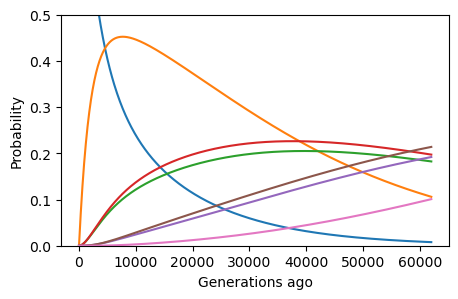

In [7]:
predicted_IPs = np.zeros((621, len(state_list)))

for idx, s in enumerate(pi_0):
    predicted_IPs[0][state_dict[idx]] += s

Qn = update_Q(Q, 7e-5, 7e-5, 1/(2*20_000), 1/(2*100_000), me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)
    
current_state = pi_0
# calculate the matrix exponential just once
Qnt = scipy.linalg.expm(Qn*100)
# update the state across time points
for t_idx, t in enumerate(range(100, 62_100, 100)):
    current_state = np.matmul(current_state, Qnt)
    # collect info
    for idx, s in enumerate(current_state):
        predicted_IPs[t_idx+1][state_dict[idx]] += s

fig, ax = plt.subplots()
fig.set_size_inches(5, 3)
for s in range(len(state_list)):
    plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,s])
ax.set_ylim(0, 0.5)
ax.set_ylabel("Probability")
ax.set_xlabel("Generations ago")
plt.show()

Note that the results above are for a time-homogenous process, i.e. the rate of migration and coalescence are constant. We want to instead have a history where these rates change. This can be obtained by having different rates for different time epochs, and then updating Q each time an epoch boundary is hit.

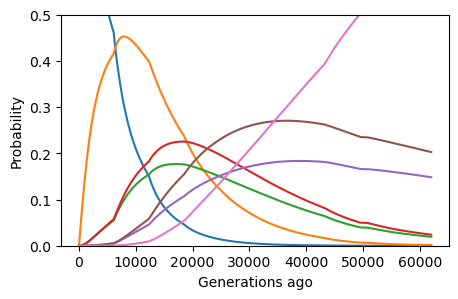

In [8]:
# take parameter for the best fitting continuous gene flow as an example
t_vals = [t for t in range(6200, 62000, 6200)] # epochs of fixed size
# NeA varies across epochs
NeA_vals = [30902.3, 9677.94, 4567.48, 2974.12, 2772.13, 2632.78, 2547.90, 1520.37, 19760.3, 22448.7]
# NeB is fixed
NeB_vals = [100_000] * 10
# start of migration (after 8000 gens)
t0 = 1343.49
# merging of pops (after 8000 gens)
t1 = 50879.79
# migration rate between t0 and t1
me_AB = 0.000078732

after_t0 = False
after_t1 = False

Qn_epoched = [Q] * 13
epoch_boundaries = [0]
epoch_counter = 1

# for the first epoch Q will always be this
Qn_epoched[0] = update_Q(Q, 0, 0, 1 / (2*NeA_vals[0]), 1 / (2*NeB_vals[0]), me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)

# the addition of flexible t0 and t1 times means we have to loop across t_vals and check whether
# t0 or t1 need to be added, as these events change the migration rates between pops

for idx, t in enumerate(t_vals):
    if t > t0 and after_t0 == False:
        Qn_epoched[epoch_counter] = update_Q(Q, me_AB, me_AB, 1 / (2*NeA_vals[idx]), 1 / (2*NeB_vals[idx]), 
                                             me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)
        epoch_boundaries.append(t0)
        epoch_counter += 1
        Qn_epoched[epoch_counter] = update_Q(Q, me_AB, me_AB, 1 / (2*NeA_vals[idx+1]), 1 / (2*NeB_vals[idx+1]), 
                                             me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)
        epoch_boundaries.append(t)
        epoch_counter += 1
        after_t0 = True
    elif after_t0 == False:
        Qn_epoched[epoch_counter] = update_Q(Q, 0, 0, 1 / (2*NeA_vals[idx+1]), 1 / (2*NeB_vals[idx+1]), 
                                             me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)
        epoch_boundaries.append(t)
        epoch_counter += 1
    elif t > t1 and after_t1 == False:
        Qn_epoched[epoch_counter] = update_Q(Q, 0.5, 0, 1 / (2*NeA_vals[idx]), 1 / (2*NeB_vals[idx]), 
                                             me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)
        epoch_boundaries.append(t1)
        epoch_counter += 1
        Qn_epoched[epoch_counter] = update_Q(Q, 0.5, 0, 1 / (2*NeA_vals[idx+1]), 1 / (2*NeB_vals[idx+1]), 
                                             me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)
        epoch_boundaries.append(t)
        epoch_counter += 1
        after_t1 = True
    elif after_t1 == True:
        Qn_epoched[epoch_counter] = update_Q(Q, 0.5, 0, 1 / (2*NeA_vals[idx+1]), 1 / (2*NeB_vals[idx+1]), 
                                             me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)
        epoch_boundaries.append(t)
        epoch_counter += 1
    else:
        Qn_epoched[epoch_counter] = update_Q(Q, me_AB, me_AB, 1 / (2*NeA_vals[idx+1]), 1 / (2*NeB_vals[idx+1]), 
                                             me_A_indices, me_B_indices, coal_A_indices, coal_B_indices)
        epoch_boundaries.append(t)
        epoch_counter += 1
    

epoch_boundaries.append(1e8)


# collect time point results here
predicted_IPs = np.zeros((621, len(state_list)))

# the first time point is zero
for idx, s in enumerate(pi_0):
    predicted_IPs[0][state_dict[idx]] += s
    
current_state = pi_0
current_epoch = 0

Qnt = scipy.linalg.expm(Qn_epoched[current_epoch]*100)

# although we are only interested in the 621 evenly spaced time points
# we do still need to update the vector at t0 and t1
time_points = sorted([dt for dt in range(0, 62_100, 100)] + [t0, t1])
output_time_points = [dt for dt in range(0, 62_100, 100)]
idx_adjust = 0 # this is used below to avoid index errors

for t_idx in range(1, len(time_points)):
    # if the time point has gone into the next epoch then calculate a new matrix exponential
    if time_points[t_idx] >= epoch_boundaries[current_epoch+1]:
        current_epoch += 1
        Qnt = scipy.linalg.expm(Qn_epoched[current_epoch]*(time_points[t_idx] - time_points[t_idx-1]))
    # if the gap between time points is not the same as the last one (t0 and t1 flexibility cause this)
    # then calculate a new matrix exponential
    elif (time_points[t_idx] - time_points[t_idx-1]) != (time_points[t_idx-1] - time_points[t_idx-2]):
        Qnt = scipy.linalg.expm(Qn_epoched[current_epoch]*(time_points[t_idx] - time_points[t_idx-1]))

    # update the state vector by vector-matrix multiplication
    current_state = np.matmul(current_state, Qnt)

    # collect info for the time point (unless it is t0 or t1)
    if time_points[t_idx] in output_time_points:
        for idx, s in enumerate(current_state):
            predicted_IPs[t_idx-idx_adjust][state_dict[idx]] += s
    else:
        idx_adjust += 1
        

fig, ax = plt.subplots()
fig.set_size_inches(5, 3)
for s in range(len(state_list)):
    plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,s])
ax.set_ylim(0, 0.5)
ax.set_ylabel("Probability")
ax.set_xlabel("Generations ago")
plt.show()

The results for the time inhomogenous process above reflect the epoch structure and timing of gene flow.

Are these calculations correct? We can check my simulating the same demography using msprime.

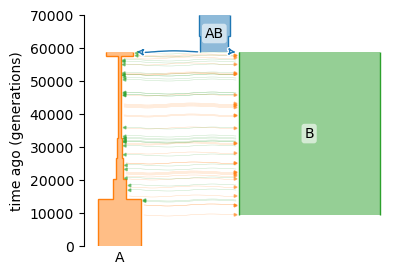

In [9]:
demography = msprime.Demography()

NeA0=30902.3;
NeA1=9677.94;
NeA2=4567.48;
NeA3=2974.12;
NeA4=2772.13;
NeA5=2632.78;
NeA6=2547.9;
NeA7=1520.37;
NeA8=19760.3;
NeA9=22448.7;
NeB=100000.;
mAB=0.000078732;
tm=1343.49;
ts=49536.3;


demography.add_population(name="A", initial_size=NeA0)
demography.add_population(name="AB", initial_size=NeA8)
demography.add_population(name="B", initial_size=NeB)

demography.add_population_parameters_change(time=6200 + 8000, population="A", initial_size=NeA1)
demography.add_population_parameters_change(time=12_400 + 8000, population="A", initial_size=NeA2)
demography.add_population_parameters_change(time=18_600 + 8000, population="A", initial_size=NeA3)
demography.add_population_parameters_change(time=24_800 + 8000, population="A", initial_size=NeA4)
demography.add_population_parameters_change(time=31_000 + 8000, population="A", initial_size=NeA5)
demography.add_population_parameters_change(time=37_200 + 8000, population="A", initial_size=NeA6)
demography.add_population_parameters_change(time=43_400 + 8000, population="A", initial_size=NeA7)
demography.add_population_parameters_change(time=49_600 + 8000, population="A", initial_size=NeA8)

demography.add_population_parameters_change(time=55_800 + 8000, population="AB", initial_size=NeA9)
demography.add_population_split(time=tm+ts+8000, derived=["A", "B"], ancestral="AB")

demography.set_symmetric_migration_rate(["A", "B"], 0)
demography.add_migration_rate_change(time = tm + 8000, rate = mAB, source="A", dest="B")
demography.add_migration_rate_change(time = tm + 8000, rate = mAB, source="B", dest="A")


demography.sort_events()

demes_graph = demography.to_demes()

# Modify pop B's end time directly before plotting
for pop in demes_graph.demes:
    if pop.name == "B":
        # Set the epochs to end at your admixture time
        pop.epochs[-1].end_time = tm+8000  # or whatever your admixture time is

fig, ax = plt.subplots()
fig.set_size_inches(4, 3)

demesdraw.tubes(demes_graph, num_lines_per_migration=30, log_time=False, seed=1234, ax=ax, max_time=70000)

plt.show()


        

We then need a way to calculate integer partitions from tree sequences. This can be done taking a subsample of n=5 at some locus and recording the coalescence events for those five lineages. Interestingly, the number of lineages that coalescence at the third event is enough to know which integer partition states are visited in the chain. I worked this out by hand for n=5, but similar logic probably applies to larger samples sizes.

Note that the code below is specific to n=5, whereas everything above was general.

In [10]:
# which topologically informative IPs did the chain visit?
def DIP(coal_times):
    third_coal = list(dict.fromkeys(coal_times))[2]
    count_third_coal = coal_times.count(third_coal)
    if count_third_coal == 3:
        return ((3, 1, 1), (4, 1))
    if count_third_coal == 1:
        return ((3, 1, 1), (3, 2))
    if count_third_coal == 4:
        return ((2, 2, 1), (4, 1))
    if count_third_coal == 2:
        return ((2, 2, 1), (3, 2))
    else:
        return None

# update the partition distribution
def update_IPs(unique_coal, DIP_val, f_11111, f_2111, f_311, f_221, f_41, f_32, f_5):
    coal_idx = 0
    for t in range(0, 621):
        time = 8000 + t * 100
        while coal_idx < len(unique_coal) and time >= unique_coal[coal_idx]:
            coal_idx += 1
        if coal_idx >= 4:
            f_5[t] += 1
        elif coal_idx == 0:
            f_11111[t] += 1
        elif coal_idx == 1:
            f_2111[t] += 1
        elif coal_idx == 2:
            if DIP_val[0] == (3, 1, 1):
                f_311[t] += 1
            elif DIP_val[0] == (2, 2, 1):
                f_221[t] += 1
        elif coal_idx == 3:
            if DIP_val[1] == (4, 1):
                f_41[t] += 1
            elif DIP_val[1] == (3, 2):
                f_32[t] += 1
    return f_11111, f_2111, f_311, f_221, f_41, f_32, f_5

Using these two functions we can loop through trees and get a Monte Carlo approximation of the integer partition distributions for this demography. The code beloe is essentially the same as that used for the human tree sequences.

In [11]:
f_11111 = np.zeros(621, dtype=np.int64)
f_2111 = np.zeros(621, dtype=np.int64)
f_311 = np.zeros(621, dtype=np.int64)
f_221 = np.zeros(621, dtype=np.int64)
f_41 = np.zeros(621, dtype=np.int64)
f_32 = np.zeros(621, dtype=np.int64)
f_5 = np.zeros(621, dtype=np.int64)
total_f = 0

ts_reps = msprime.sim_ancestry(
    samples={"A" : 50}, 
    demography=demography,
    ploidy=2, # diploid
    recombination_rate=1e-8, 
    sequence_length=1e5, 
    discrete_genome=True, 
    random_seed = 44, 
    num_replicates=1000
)

# loop through ts_reps
for ts in ts_reps:
    
    # sample every 10 kb
    for pos in range(0, int(ts.sequence_length), 10_000):
            
        tree = ts.at(pos)
        # guards against malformed trees
        if tree.num_roots == 1:
            n_lineages = 0
            focal_nodes = []
            for node in tree.nodes():
                # we need to collect at least five lineages still present at 8000 gens
                if tree.time(node) < 8_000 and (tree.parent(node) == tskit.NULL or tree.time(tree.parent(node)) >= 8_000):
                    n_lineages += 1
                    focal_nodes.append(node)
            if len(focal_nodes) >= 5:
                for x in range(100): # take 100 random samples
                    total_f += 1 # counting total samples
                    sample_nodes = random.sample(focal_nodes, 5)
                    coal_times = []
                    for i in range(0, len(sample_nodes)-1):
                        for j in range(i+1, len(sample_nodes)):
                            coal_times.append(tree.time(tree.mrca(sample_nodes[i], sample_nodes[j])))
                    coal_times = sorted(coal_times)
                    DIP_val = DIP(coal_times)
                    unique_coal = list(dict.fromkeys(coal_times))
        
                    f_11111, f_2111, f_311, f_221, f_41, f_32, f_5 = update_IPs(unique_coal, DIP_val, f_11111, f_2111, f_311, f_221, f_41, f_32, f_5)


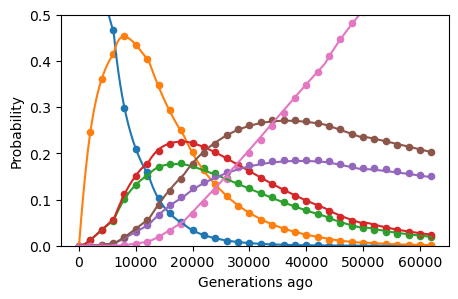

In [12]:
fig, ax = plt.subplots()
fig.set_size_inches(5, 3)

for s in range(len(state_list)):
    plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,s])

plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(f_11111)[0::20] / total_f, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(f_2111)[0::20] / total_f, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(f_221)[0::20] / total_f, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(f_311)[0::20] / total_f, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(f_32)[0::20] / total_f, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(f_41)[0::20] / total_f, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(f_5)[0::20] / total_f, s=20)

ax.set_ylim(0, 0.5)
ax.set_ylabel("Probability")
ax.set_xlabel("Generations ago")
plt.show()

Good news! The simulated integer partition distributions match the analytic predictions almost perfectly.

The model we have been doing calculations for is the maximum composite likelihoood continuous gene flow model. So, the distributions above should fit the data well. We can load in the human integer partition distributions to check this.

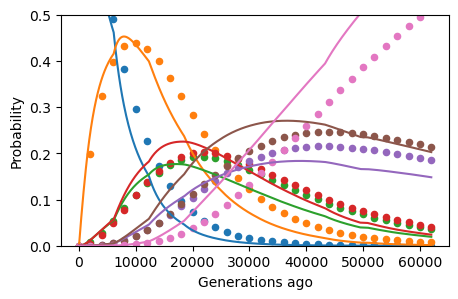

In [13]:
human_f_11111 = np.loadtxt("hg38_integer_partitions/f_11111.txt")
human_f_2111 = np.loadtxt("hg38_integer_partitions/f_2111.txt")
human_f_221 = np.loadtxt("hg38_integer_partitions/f_221.txt")
human_f_311 = np.loadtxt("hg38_integer_partitions/f_311.txt")
human_f_32 = np.loadtxt("hg38_integer_partitions/f_32.txt")
human_f_41 = np.loadtxt("hg38_integer_partitions/f_41.txt")
human_f_5 = np.loadtxt("hg38_integer_partitions/f_5.txt")
human_f_total = np.loadtxt("hg38_integer_partitions/f_total.txt")

fig, ax = plt.subplots()
fig.set_size_inches(5, 3)

for s in range(len(state_list)):
    plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,s])

plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_11111)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_2111)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_221)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_311)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_32)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_41)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_5)[0::20] / human_f_total, s=20)

ax.set_ylim(0, 0.5)
ax.set_ylabel("Probability")
ax.set_xlabel("Generations ago")
plt.show()

Not great... But recall from the main text that bias from genealogy inference was accounted for when model fitting. Let's see if adding the bias correction helps.

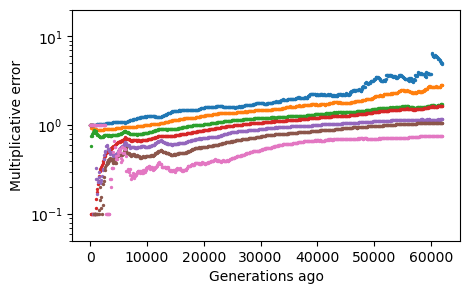

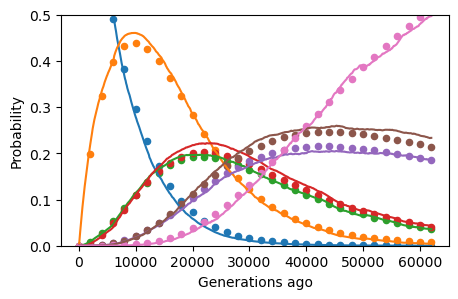

In [14]:
bias_f_11111 = np.loadtxt("hg38_integer_partitions/Continuous_bootstrap.bias.f_11111.txt")
bias_f_2111 = np.loadtxt("hg38_integer_partitions/Continuous_bootstrap.bias.f_2111.txt")
bias_f_221 = np.loadtxt("hg38_integer_partitions/Continuous_bootstrap.bias.f_221.txt")
bias_f_311 = np.loadtxt("hg38_integer_partitions/Continuous_bootstrap.bias.f_311.txt")
bias_f_32 = np.loadtxt("hg38_integer_partitions/Continuous_bootstrap.bias.f_32.txt")
bias_f_41 = np.loadtxt("hg38_integer_partitions/Continuous_bootstrap.bias.f_41.txt")
bias_f_5 = np.loadtxt("hg38_integer_partitions/Continuous_bootstrap.bias.f_5.txt")

normalisation_vec = predicted_IPs[:,0] * bias_f_11111[0:621] + \
predicted_IPs[:,1] * bias_f_2111[0:621] + \
predicted_IPs[:,2] * bias_f_221[0:621] + \
predicted_IPs[:,3] * bias_f_311[0:621] + \
predicted_IPs[:,4] * bias_f_32[0:621] + \
predicted_IPs[:,5] * bias_f_41[0:621] + \
predicted_IPs[:,6] * bias_f_5[0:621]

fig, ax = plt.subplots()
fig.set_size_inches(5, 3)

plt.scatter([t*100 for t in range(0, 621)], bias_f_11111[0:621], s=2)
plt.scatter([t*100 for t in range(0, 621)], bias_f_2111[0:621], s=2)
plt.scatter([t*100 for t in range(0, 621)], bias_f_221[0:621], s=2)
plt.scatter([t*100 for t in range(0, 621)], bias_f_311[0:621], s=2)
plt.scatter([t*100 for t in range(0, 621)], bias_f_32[0:621], s=2)
plt.scatter([t*100 for t in range(0, 621)], bias_f_41[0:621], s=2)
plt.scatter([t*100 for t in range(0, 621)], bias_f_5[0:621], s=2)

ax.set_yscale("log")
ax.set_ylim(0.05, 20)
ax.set_ylabel("Multiplicative error")
ax.set_xlabel("Generations ago")
plt.show()

fig, ax = plt.subplots()
fig.set_size_inches(5, 3)

plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,0] * bias_f_11111[0:621] / normalisation_vec)
plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,1] * bias_f_2111[0:621] / normalisation_vec)
plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,2] * bias_f_221[0:621] / normalisation_vec)
plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,3] * bias_f_311[0:621] / normalisation_vec)
plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,4] * bias_f_32[0:621] / normalisation_vec)
plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,5] * bias_f_41[0:621] / normalisation_vec)
plt.plot([t*100 for t in range(0, 621)], predicted_IPs[:,6] * bias_f_5[0:621] / normalisation_vec)

plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_11111)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_2111)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_221)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_311)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_32)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_41)[0::20] / human_f_total, s=20)
plt.scatter([t*100 for t in range(0, 621)][0::20], np.array(human_f_5)[0::20] / human_f_total, s=20)

ax.set_ylim(0, 0.5)
ax.set_ylabel("Probability")
ax.set_xlabel("Generations ago")
plt.show()

Much better!